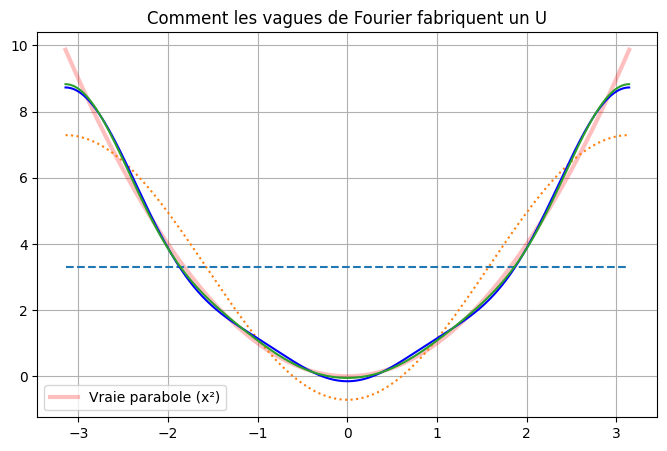

In [5]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-np.pi, np.pi, 1000)

# 1. La vraie parabole
y_vraie = x**2

# 2. L'assemblage de Fourier (on ajoute les pièces une par une)
fourier_0 = 3.29 * np.ones_like(x)
fourier_1 = 3.29 - 4 * np.cos(x)
fourier_2 = 3.29 - 4 * np.cos(x) + 1 * np.cos(2 * x)
fourier_3 = 3.29 - 4 * np.cos(x) + 1 * np.cos(2 * x) - 0.44 * np.cos(3 * x)
fourier_4 = 3.29 - 4 * np.cos(x) + 1 * np.cos(2 * x) - 0.44 * np.cos(3 * x) + 0.1 * np.cos(4 * x)

# Graphique
plt.figure(figsize=(8, 5))
plt.plot(x, y_vraie, "r-", label="Vraie parabole (x²)", linewidth=3, alpha=0.25)
plt.plot(x, fourier_0, "--")
plt.plot(x, fourier_1, ":")
plt.plot(x, fourier_3, "b-")
plt.plot(x, fourier_4)

plt.grid(True)
plt.legend()
plt.title("Comment les vagues de Fourier fabriquent un U")
plt.show()

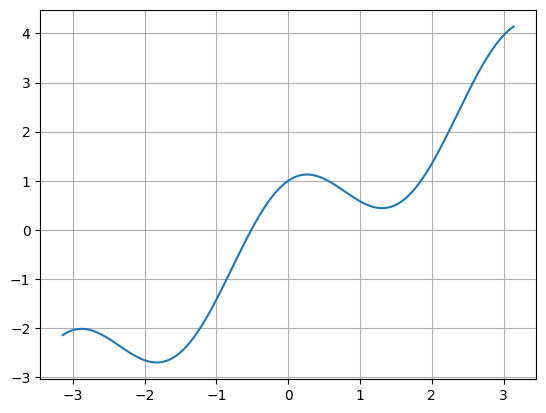

In [5]:
x = np.linspace(-np.pi, np.pi, 1000)
y = x + np.cos(2*x)

plt.plot(x, y)
plt.grid(True)
plt.show()

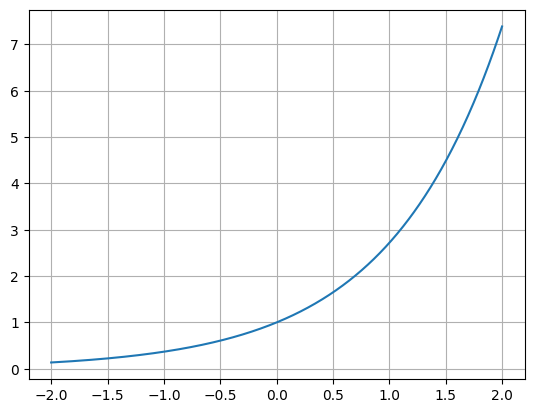

In [49]:
x = np.linspace(-2, 2, 1000)
y = np.exp(x)

plt.plot(x, y)
plt.grid(True)
plt.show()

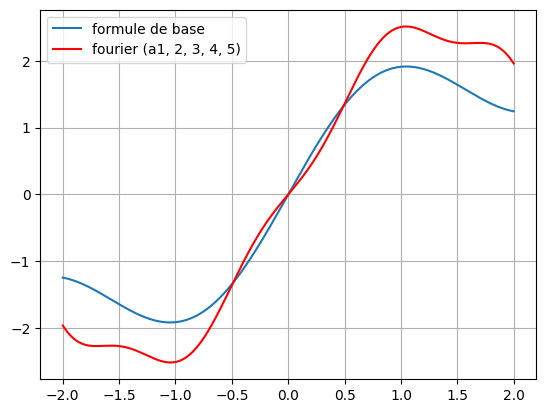

In [42]:
import math
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-2, 2, 1000)
y = x + np.sin(2*x)
z = 2*np.sin(x) + 1*np.sin(2*x) - 0.66*np.sin(3*x) + 0.5*np.sin(4*x) - 0.4*np.sin(5*x)

plt.plot(x, y, label="formule de base")
plt.plot(x, z, "r-", label="fourier (a1, 2, 3, 4, 5)")

plt.grid(True)
plt.legend()
plt.show()



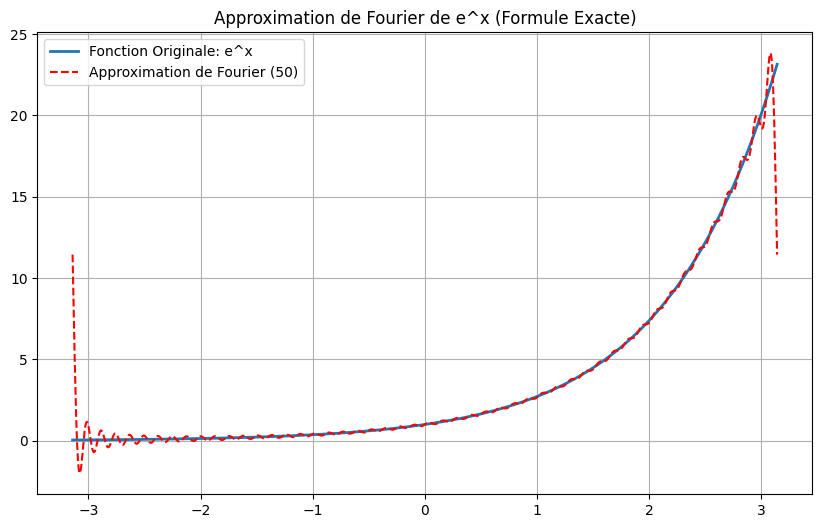

In [4]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-np.pi, np.pi, 1000)
y_vraie = np.exp(x)

# Le vrai a0 théorique
a0 = np.sinh(np.pi) / np.pi

A_coefficients = []
B_coefficients = []
zz = 50

# Le facteur commun devant les formules
facteur = (2 * np.sinh(np.pi)) / np.pi

for i in range(1, zz):
    # Formules exactes théoriques
    ai = facteur * ((-1) ** i) / (1 + i**2)
    bi = facteur * ((-1) ** (i + 1) * i) / (1 + i**2)

    A_coefficients.append(ai)
    B_coefficients.append(bi)

# 3. La reconstruction
y_fourier = a0 * np.ones_like(x)
for i in range(1, zz):
    y_fourier += A_coefficients[i - 1] * np.cos(i * x) + B_coefficients[
        i - 1
    ] * np.sin(i * x)

# 4. Le graphique
plt.figure(figsize=(10, 6))
plt.plot(x, y_vraie, label="Fonction Originale: e^x", linewidth=2)
plt.plot(
    x,
    y_fourier,
    "r--",
    label=f"Approximation de Fourier ({zz})",
    linewidth=1.5,
)
plt.title("Approximation de Fourier de e^x (Formule Exacte)")
plt.grid(True)
plt.legend()
plt.show()

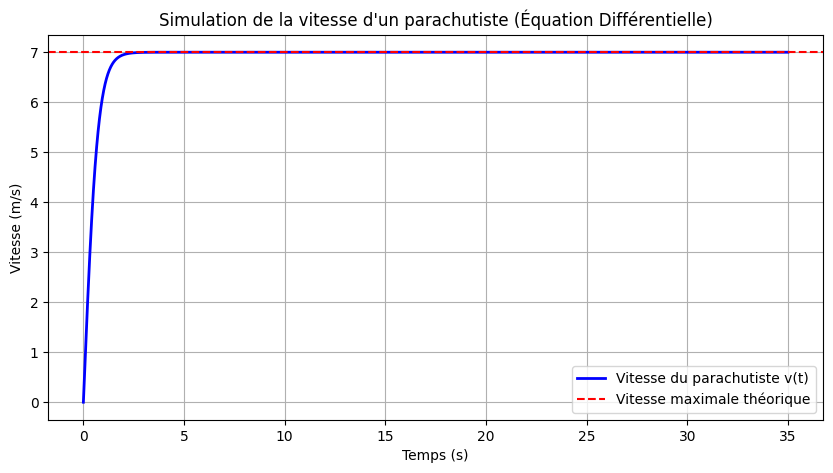

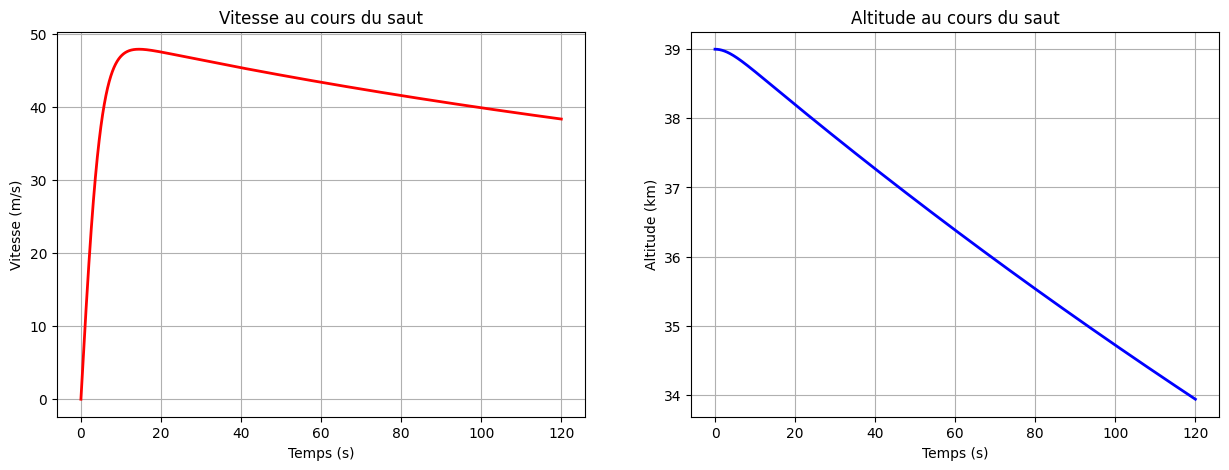

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Paramètres de la simulation
dt = 0.01  # Le petit pas de temps (en secondes)
temps_total = 35  # On simule pendant 35 secondes
nb_pas = int(temps_total / dt)

# Tableaux pour stocker le temps et la vitesse
t = np.zeros(nb_pas)
v = np.zeros(nb_pas)

# Conditions initiales : au temps t=0, la vitesse v=0
t[0] = 0
v[0] = 0

# 2. La boucle de simulation (Méthode d'Euler)
for i in range(1, nb_pas):
    # On calcule l'accélération à cet instant précis
    acceleration = 9.81 - 0.2 * (v[i - 1] ** 2)

    # Euler : Nouvelle vitesse = ancienne + acceleration * dt
    v[i] = v[i - 1] + acceleration * dt
    t[i] = t[i - 1] + dt

# 3. Affichage du graphique
plt.figure(figsize=(10, 5))
plt.plot(t, v, "b-", linewidth=2, label="Vitesse du parachutiste v(t)")
plt.axhline(
    y=np.sqrt(9.81 / 0.2),
    color="r",
    linestyle="--",
    label="Vitesse maximale théorique",
)
plt.title("Simulation de la vitesse d'un parachutiste (Équation Différentielle)")
plt.xlabel("Temps (s)")
plt.ylabel("Vitesse (m/s)")
plt.grid(True)
plt.legend()
plt.show()
import matplotlib.pyplot as plt
import numpy as np

dt = 0.01
temps_total = 120  # On le regarde tomber pendant 2 minutes
nb_pas = int(temps_total / dt)

t = np.zeros(nb_pas)
v = np.zeros(nb_pas)
z = np.zeros(nb_pas)  # Nouveau tableau pour l'altitude

# Conditions initiales (Saut depuis la stratosphère)
t[0] = 0
v[0] = 0
z[0] = 39000  # 39 km de haut

for i in range(1, nb_pas):
    # Densité de l'air qui dépend de l'altitude précédente
    densite_air = np.exp(-z[i - 1] / 10000)

    # L'accélération avec le freinage variable
    acceleration = 9.81 - 0.2 * densite_air * (v[i - 1] ** 2)

    # Méthode d'Euler pour la vitesse
    v[i] = v[i - 1] + acceleration * dt

    # Méthode d'Euler pour l'altitude : l'altitude diminue à cause de la vitesse
    z[i] = z[i - 1] - v[i - 1] * dt
    t[i] = t[i - 1] + dt

# Affichage des deux graphiques côte à côte
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Graphique 1 : La vitesse
ax1.plot(t, v, "r-", linewidth=2)
ax1.set_title("Vitesse au cours du saut")
ax1.set_xlabel("Temps (s)")
ax1.set_ylabel("Vitesse (m/s)")
ax1.grid(True)

# Graphique 2 : L'altitude
ax2.plot(t, z / 1000, "b-", linewidth=2)
ax2.set_title("Altitude au cours du saut")
ax2.set_xlabel("Temps (s)")
ax2.set_ylabel("Altitude (km)")
ax2.grid(True)

plt.show()

### Évolution du Pourcentage de 'Pile' par Pièce

Pour visualiser comment le pourcentage de 'pile' évolue pour chaque pièce et converge vers la probabilité théorique de 51%, nous allons calculer le pourcentage cumulatif de 'pile' après chaque lancer pour chaque pièce et le tracer sur un graphique. Cela illustre la loi des grands nombres.

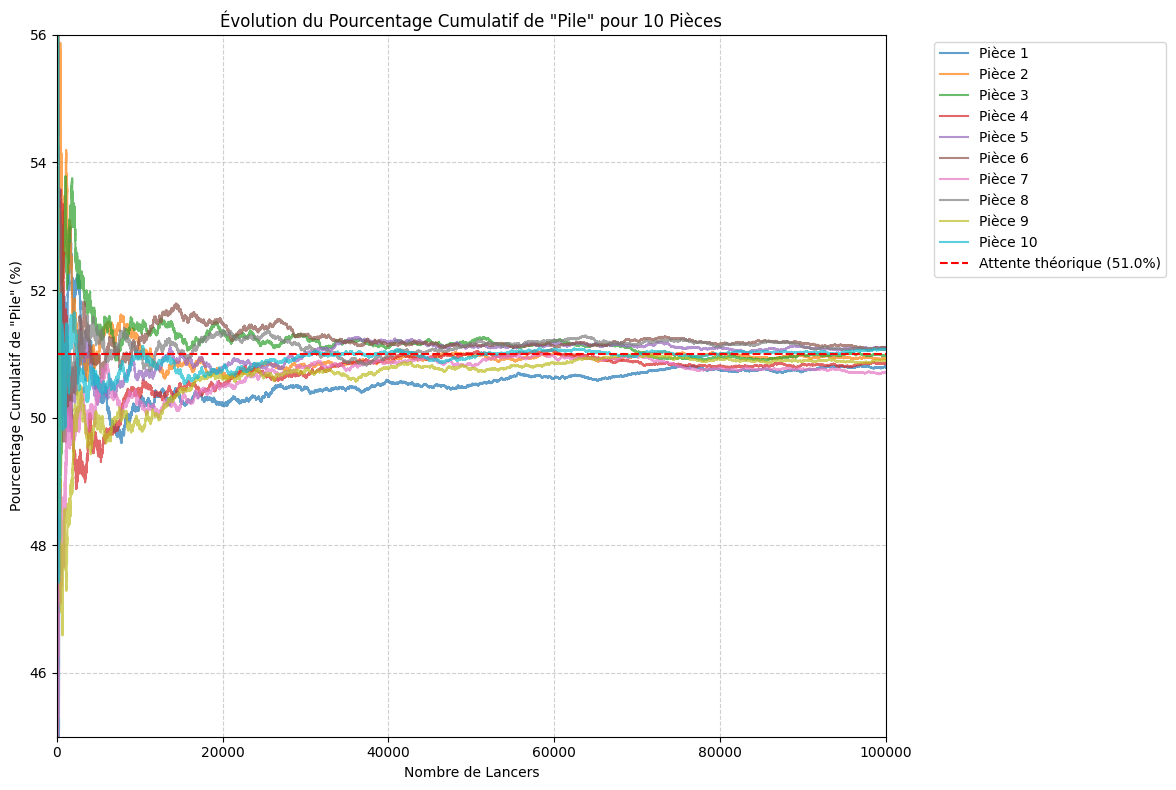

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres de la simulation (reprises des valeurs précédentes)
prob_pile = 0.51  # Probabilité d'obtenir 'pile'
nombre_pieces = 10  # Nombre de pièces différentes
nombre_lancers_par_piece = 100000  # Nombre de lancers par pièce

plt.figure(figsize=(12, 8))

# Simulation des lancers pour chaque pièce et tracé de l'évolution du pourcentage
for i in range(nombre_pieces):
    # np.random.rand(n) génère n nombres aléatoires entre 0 et 1
    # Si le nombre est inférieur à prob_pile, on considère que c'est 'pile'
    lancers = np.random.rand(nombre_lancers_par_piece) < prob_pile

    # Calcul du nombre cumulatif de 'pile'
    cumulative_pile_count = np.cumsum(lancers)

    # Calcul du pourcentage cumulatif de 'pile'
    # On divise par (indices + 1) pour avoir le nombre de lancers actuel
    cumulative_percentage = (cumulative_pile_count / (np.arange(nombre_lancers_par_piece) + 1)) * 100

    # Tracé de l'évolution pour chaque pièce
    plt.plot(cumulative_percentage, label=f'Pièce {i+1}', alpha=0.7)

# Ligne horizontale pour l'attente théorique (51%)
plt.axhline(y=prob_pile*100, color='r', linestyle='--', label=f'Attente théorique ({prob_pile*100}%)')

plt.xlabel('Nombre de Lancers')
plt.ylabel('Pourcentage Cumulatif de "Pile" (%)')
plt.title(f'Évolution du Pourcentage Cumulatif de "Pile" pour {nombre_pieces} Pièces')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.xlim(0, nombre_lancers_par_piece)
plt.ylim(45, prob_pile*100+5)
plt.show()

### Illustration de la Loi Normale pour le Nombre de 'Pile'

Lorsque l'on effectue un grand nombre de lancers pour une pièce, le nombre de fois où 'pile' apparaît suit une distribution binomiale. Pour un grand nombre de lancers (comme 100 000 ici), la distribution binomiale peut être très bien approximée par une loi normale.

Nous allons tracer cette courbe de loi normale théorique. Le pic de cette courbe représentera le nombre de 'pile' le plus probable, et sa largeur (déterminée par l'écart-type) indiquera la dispersion des résultats possibles autour de cette moyenne.

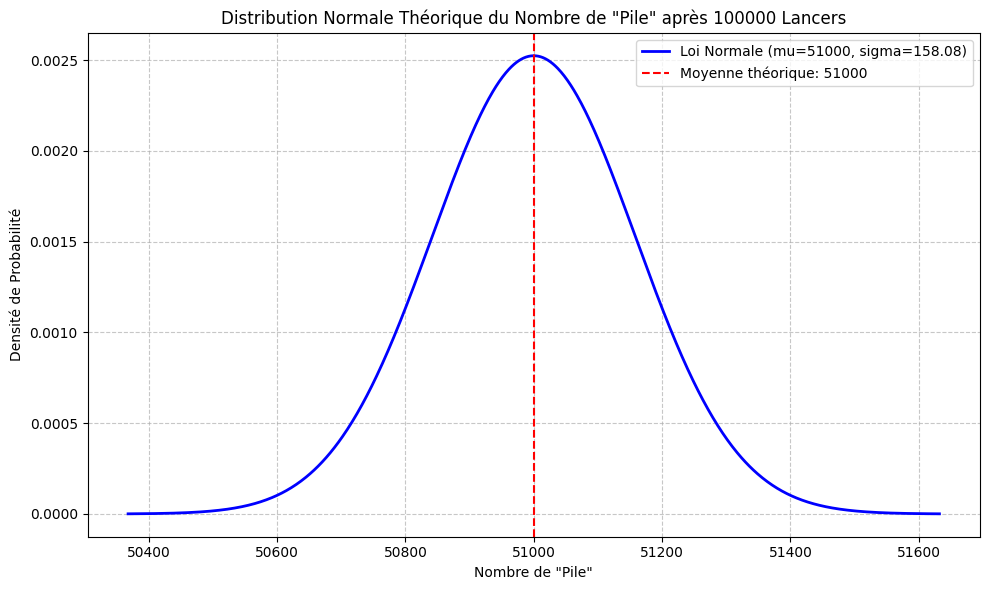

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Reprise des paramètres de la simulation précédente
prob_pile = 0.51  # Probabilité d'obtenir 'pile'
nombre_lancers_par_piece = 100000  # Nombre de lancers par pièce

# Calcul des paramètres de la loi normale (approximation de la binomiale)
# La moyenne (mu) est n * p
mu = nombre_lancers_par_piece * prob_pile
# L'écart-type (sigma) est sqrt(n * p * (1-p))
sigma = np.sqrt(nombre_lancers_par_piece * prob_pile * (1 - prob_pile))

# Création d'un ensemble de valeurs x pour tracer la distribution
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)

# Calcul de la fonction de densité de probabilité (PDF) de la loi normale
pd = norm.pdf(x, mu, sigma)

# Tracé de la courbe de la loi normale
plt.figure(figsize=(10, 6))
plt.plot(x, pd, color='blue', linewidth=2, label=f'Loi Normale (mu={mu:.0f}, sigma={sigma:.2f})')

# Marquer la moyenne sur le graphique
plt.axvline(mu, color='red', linestyle='--', label=f'Moyenne théorique: {mu:.0f}')

plt.title(f'Distribution Normale Théorique du Nombre de "Pile" après {nombre_lancers_par_piece} Lancers')
plt.xlabel('Nombre de "Pile"')
plt.ylabel('Densité de Probabilité')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()